# Cuaderno 06 · Grafos causales (DAGs) y d-separación

### Serie *Inferencia Causal + IA Explicativa* · Capítulo 6 de 10

> Cuaderno reproducible asociado al artículo divulgativo **«De la correlación a la causa: inteligencia artificial explicable e inferencia causal»**. Datos abiertos; ejecución completa.

---

El cuaderno 05 dejó una pregunta abierta: en datos observacionales, ¿**qué** variables hay que ajustar para identificar un efecto? Ajustar de más puede ser tan dañino como ajustar de menos (lo vimos con el colisionador en el cuaderno 01). La respuesta no es estadística sino **estructural**, y se expresa con un lenguaje gráfico: los **grafos acíclicos dirigidos** (DAGs) y el criterio de **d-separación**. Este capítulo los desarrolla con definiciones, un teorema y demostraciones numéricas, hasta el **criterio de puerta trasera** que dice exactamente qué conjunto de ajuste identifica el efecto. Se cierra construyendo un DAG para el programa de empleo del cuaderno 05.

## Contenido y objetivos

1. **Grafos causales (DAG)** — definición y las tres estructuras elementales (cadena, bifurcación, colisionador).
2. **d-separación** — caminos bloqueados, el teorema que la liga a la independencia condicional, y su **verificación numérica**.
3. **Tres roles** — confusor, mediador y colisionador: cuándo ajustar y cuándo **no**.
4. **Criterio de puerta trasera** — la regla de identificación, con una demostración cuantitativa de que solo el conjunto correcto recupera el ATE.
5. **Un DAG para el NSW** — el conjunto de ajuste válido del programa de empleo.

**Objetivos.** (i) Leer un DAG y clasificar sus caminos; (ii) aplicar la d-separación y comprobar que predice las independencias en los datos; (iii) distinguir confusor / mediador / colisionador; (iv) **enunciar y verificar** el criterio backdoor; (v) trasladarlo a un problema real.

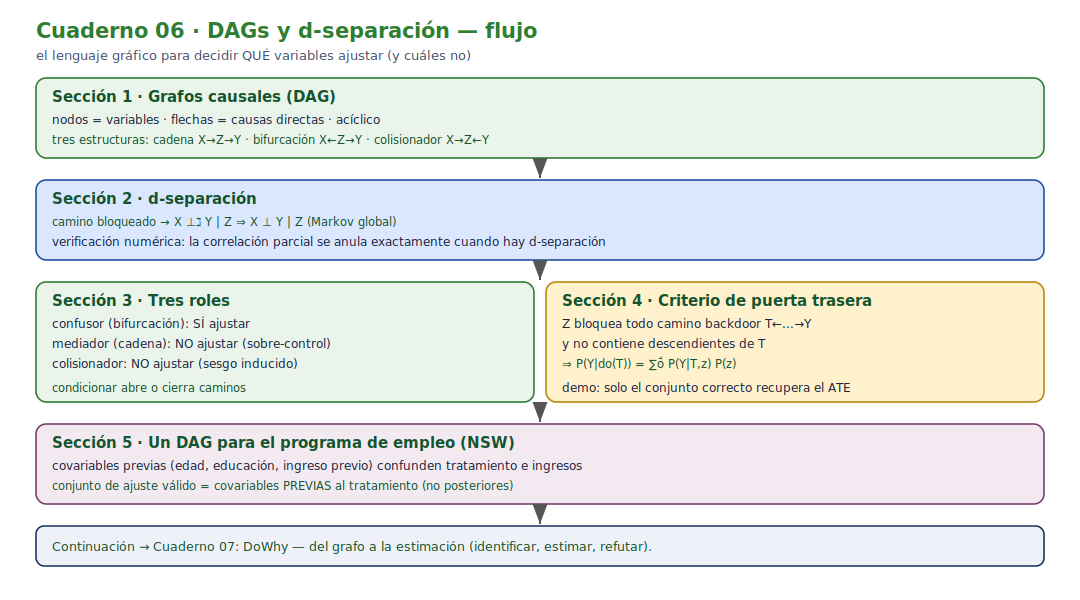

In [1]:
# Diagrama de flujo del cuaderno (se incrusta en la salida)
from pathlib import Path
from IPython.display import SVG, display
_svg = Path('../img/06_flujo.svg')
if not _svg.exists():
    _svg = Path('img/06_flujo.svg')
display(SVG(filename=str(_svg)))

In [2]:
# Configuración y utilidades de grafos
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.linear_model import LinearRegression

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE); np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.figsize": (7, 4.2), "axes.grid": False})

def dibujar_dag(G, pos, ax, titulo="", color_nodos=None, cond=None):
    cond = cond or set()
    colores = [("#fde0a8" if nodo in cond else (color_nodos or "#dbe7ff")) for nodo in G.nodes]
    bordes = ["#b8860b" if nodo in cond else "#1f4e9c" for nodo in G.nodes]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colores, node_size=1300, edgecolors=bordes, linewidths=2)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=12, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, arrowsize=22, edge_color="#555", width=1.8, node_size=1300)
    ax.set_title(titulo, fontsize=11); ax.axis("off")

def d_separa(G, x, y, Z):
    X = {x} if isinstance(x, str) else set(x)
    Y = {y} if isinstance(y, str) else set(y)
    try:
        return nx.is_d_separator(G, X, Y, set(Z))
    except AttributeError:
        return nx.d_separated(G, X, Y, set(Z))

print("networkx", nx.__version__, "· utilidades listas")

networkx 3.6.1 · utilidades listas


## Sección 1 · Grafos causales (DAG)

> **Definición 1.1 (grafo acíclico dirigido, DAG).** Un *DAG causal* $G=(V,E)$ tiene por nodos $V$ a las variables y por aristas dirigidas $E$ a las **relaciones de causa directa**: $A\to B$ significa "$A$ es causa directa de $B$" (dado el resto del grafo). *Acíclico* = no hay ciclos dirigidos (nada es causa de sí mismo).

> **Definición 1.2 (camino).** Un *camino* entre dos nodos es una secuencia de aristas consecutivas, **sin importar su dirección**. Un *camino dirigido* (o causal) sigue todas las flechas en el mismo sentido.

Todo camino se descompone en tres **estructuras elementales** según la orientación de las flechas en cada nodo intermedio:

> **Definición 1.3 (estructuras elementales).** En un nodo intermedio $Z$ de un camino $X-Z-Y$:
> - **Cadena** (chain): $X\to Z\to Y$. $Z$ es **mediador**.
> - **Bifurcación** (fork): $X\leftarrow Z\to Y$. $Z$ es **causa común** (confusor).
> - **Colisionador** (collider): $X\to Z\leftarrow Y$. $Z$ es **efecto común**.

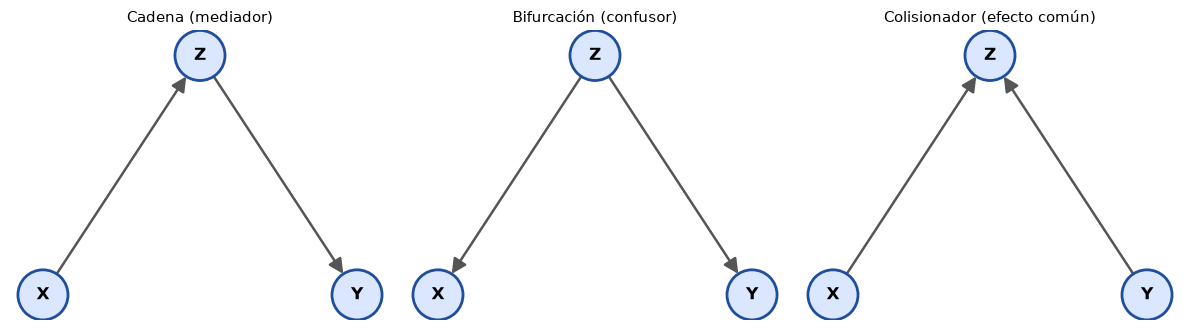

In [3]:
# Figura · las tres estructuras elementales
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
estructuras = [
    ("Cadena (mediador)", [("X", "Z"), ("Z", "Y")]),
    ("Bifurcación (confusor)", [("Z", "X"), ("Z", "Y")]),
    ("Colisionador (efecto común)", [("X", "Z"), ("Y", "Z")]),
]
pos = {"X": (0, 0), "Y": (2, 0), "Z": (1, 1)}
for ax, (titulo, edges) in zip(axes, estructuras):
    G = nx.DiGraph(edges)
    dibujar_dag(G, pos, ax, titulo)
plt.tight_layout(); plt.show()

> **Observación 1.1 (cómo fluye la asociación).** Por una **cadena** y por una **bifurcación** la asociación *fluye* (X e Y quedan correlacionadas); por un **colisionador**, en cambio, el camino está **cerrado** de origen (X e Y no se asocian *a través de* Z). Condicionar invierte estos roles: condicionar sobre el mediador o el confusor **cierra** el camino; condicionar sobre el colisionador (o un descendiente suyo) lo **abre**. Esta asimetría es el corazón de todo el capítulo.

## Sección 2 · d-separación

La d-separación traduce la estructura del grafo en afirmaciones de (in)dependencia.

> **Definición 2.1 (camino bloqueado).** Un camino entre $X$ e $Y$ está **bloqueado** por un conjunto $Z$ si contiene:
> - una **cadena** $\,\cdot\!\to W\to\cdot\,$ o una **bifurcación** $\,\cdot\!\leftarrow W\to\cdot\,$ con $W\in Z$; **o bien**
> - un **colisionador** $\,\cdot\!\to W\leftarrow\cdot\,$ con $W\notin Z$ y **ningún descendiente de $W$** en $Z$.
>
> **Definición 2.2 (d-separación).** $X$ e $Y$ están **d-separados por $Z$** (escrito $X\perp_d Y\mid Z$) si **todos** los caminos entre ellos están bloqueados por $Z$.

> **Teorema 2.1 (Markov global; Pearl, 2009).** Si la distribución $P$ es compatible (Markov) con el DAG $G$, entonces
> $$ X\perp_d Y\mid Z \ \text{ en } G \quad\Longrightarrow\quad X\perp Y\mid Z \ \text{ en } P. $$
> Es decir, **la d-separación gráfica implica independencia condicional** en los datos. (La demostración formaliza que un camino bloqueado no transmite dependencia; véase Pearl, 2009, cap. 1.)

**Ejemplo trabajado.** En el DAG $X\leftarrow Z\to Y$ y $X\to W\leftarrow Y$ (una bifurcación en $Z$ y un colisionador en $W$), analicemos $X$ e $Y$:
- **Sin condicionar**: el camino $X\leftarrow Z\to Y$ (bifurcación, $Z\notin\varnothing$) está **abierto** → $X$ e $Y$ **dependen**.
- **Condicionando en $Z$**: la bifurcación se bloquea; el camino por el colisionador $W$ sigue cerrado ($W\notin\{Z\}$) → **d-separados**.
- **Condicionando en $\{Z,W\}$**: se bloquea la bifurcación, pero condicionar el **colisionador** $W$ **abre** el camino $X\to W\leftarrow Y$ → vuelven a **depender**.

Lo verificamos con `networkx` y luego en los datos.

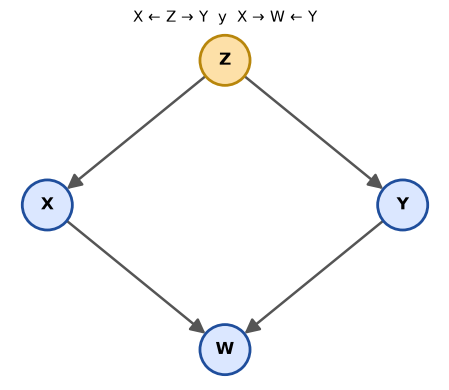

  X ⟂d Y | set()      ->  d-separados = False
  X ⟂d Y | {'Z'}      ->  d-separados = True
  X ⟂d Y | {'W', 'Z'} ->  d-separados = False
  X ⟂d Y | {'W'}      ->  d-separados = False


In [4]:
# DAG del ejemplo: bifurcación en Z, colisionador en W
G2 = nx.DiGraph([("Z", "X"), ("Z", "Y"), ("X", "W"), ("Y", "W")])
pos2 = {"Z": (1, 1.4), "X": (0, 0.4), "Y": (2, 0.4), "W": (1, -0.6)}
fig, ax = plt.subplots(figsize=(4.6, 4))
dibujar_dag(G2, pos2, ax, "X ← Z → Y  y  X → W ← Y", cond={"Z"})
plt.tight_layout(); plt.show()

for Z in [set(), {"Z"}, {"Z", "W"}, {"W"}]:
    print(f"  X ⟂d Y | {str(set(Z)):10s} ->  d-separados = {d_separa(G2, 'X', 'Y', Z)}")

In [5]:
# Verificación numérica: simular un SCM compatible con G2 y medir correlación parcial
def corr_parcial(df, x, y, Z):
    Z = list(Z)
    if Z:
        rx = df[x] - LinearRegression().fit(df[Z], df[x]).predict(df[Z])
        ry = df[y] - LinearRegression().fit(df[Z], df[y]).predict(df[Z])
    else:
        rx, ry = df[x] - df[x].mean(), df[y] - df[y].mean()
    return np.corrcoef(rx, ry)[0, 1]

n = 8000
Z = rng.normal(0, 1, n); X = Z + rng.normal(0, 1, n); Y = Z + rng.normal(0, 1, n)
W = X + Y + rng.normal(0, 1, n)
dfg = pd.DataFrame({"X": X, "Y": Y, "Z": Z, "W": W})
print(f"{'condicionado en':16s} {'d-separados':>12} {'corr. parcial':>14}")
for S in [set(), {"Z"}, {"Z", "W"}, {"W"}]:
    print(f"{str(set(S)):16s} {str(d_separa(G2,'X','Y',S)):>12} {corr_parcial(dfg,'X','Y',S):>14.3f}")

condicionado en   d-separados  corr. parcial
set()                   False          0.490
{'Z'}                    True         -0.009
{'W', 'Z'}              False         -0.498
{'W'}                   False         -0.398


La correspondencia es exacta: la **correlación parcial se anula** ($\approx 0$) precisamente cuando hay **d-separación** ($\{Z\}$), y reaparece cuando no la hay —incluyendo el caso en que condicionar el colisionador $\{Z,W\}$ *crea* asociación—. El Teorema 2.1 se cumple en los datos.

## Sección 3 · Tres roles: confusor, mediador, colisionador

Para estimar el efecto de un tratamiento $T$ sobre un resultado $Y$, cada variable adicional juega uno de tres papeles, y el grafo dicta qué hacer con ella.

> **Definición 3.1 (confusor).** Causa común de $T$ y $Y$ (bifurcación $T\leftarrow Z\to Y$). Abre un **camino de puerta trasera** y sesga la asociación. **Hay que ajustar** por él para cerrarlo.
>
> **Definición 3.2 (mediador).** Eslabón del efecto causal (cadena $T\to M\to Y$). Está **sobre** el camino causal. **No** se ajusta si se busca el efecto *total*: hacerlo elimina la parte indirecta (*sobre-control*).
>
> **Definición 3.3 (colisionador).** Efecto común de dos variables (p. ej. $T\to C\leftarrow Y$). Su camino está cerrado; **condicionarlo lo abre** e introduce sesgo. **No** se ajusta.

> **Observación 3.1 (regla práctica).** *Ajustar por causas previas comunes (confusores); nunca por descendientes del tratamiento (mediadores, colisionadores).* La tabla siguiente lo resume; las Secciones 4 y los ejemplos lo cuantifican.

| Variable | Estructura | ¿Ajustar? | Si se ajusta mal… |
|---|---|---|---|
| Confusor | $T\leftarrow Z\to Y$ | **Sí** | (no ajustar) → sesgo de confusión |
| Mediador | $T\to M\to Y$ | **No** (efecto total) | sobre-control: pierde el efecto indirecto |
| Colisionador | $T\to C\leftarrow Y$ | **No** | sesgo del colisionador (asociación inducida) |

## Sección 4 · El criterio de puerta trasera (*back-door*)

> **Definición 4.1 (camino de puerta trasera).** Un *camino de puerta trasera* de $T$ a $Y$ es un camino que **sale de $T$ por una flecha entrante** ($T\leftarrow\cdots Y$). Estos caminos —no los causales— son los que confunden el efecto.
>
> **Definición 4.2 (criterio de puerta trasera).** Un conjunto $Z$ satisface el *criterio backdoor* respecto de $(T,Y)$ si: (i) ningún nodo de $Z$ es **descendiente de $T$**; y (ii) $Z$ **bloquea todos** los caminos de puerta trasera de $T$ a $Y$.

> **Teorema 4.1 (ajuste de puerta trasera; Pearl, 2009).** Si $Z$ satisface el criterio backdoor respecto de $(T,Y)$, el efecto causal está **identificado** por el ajuste
> $$ P\big(Y\mid do(T{=}t)\big)=\sum_{z} P\big(Y\mid T{=}t,\,Z{=}z\big)\,P(z). $$
> En un modelo lineal, esto equivale a que el **coeficiente de $T$ en la regresión de $Y$ sobre $T$ y $Z$** es el efecto causal.

Lo demostramos cuantitativamente sobre un DAG con un confusor $Z$, un mediador $M$ y un colisionador $C$, donde **conocemos** el efecto total verdadero.

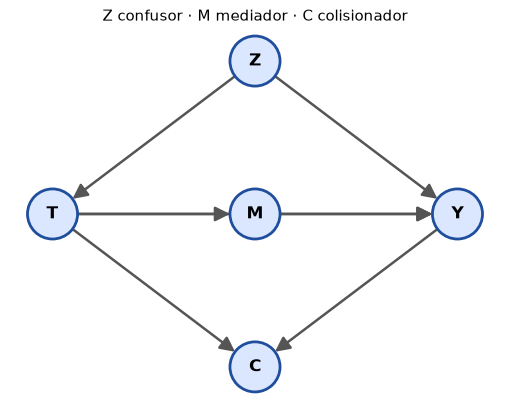

Camino de puerta trasera: T←Z→Y (puerta trasera por el confusor Z)
¿{Z} bloquea las puertas traseras y no incluye descendientes de T? -> True (Z es el ajuste válido)


In [6]:
# DAG de tratamiento con confusor (Z), mediador (M) y colisionador (C)
Gt = nx.DiGraph([("Z", "T"), ("Z", "Y"), ("T", "M"), ("M", "Y"),
                 ("T", "Y"), ("T", "C"), ("Y", "C")])
post = {"Z": (1, 2), "T": (0, 1), "M": (1, 1), "Y": (2, 1), "C": (1, 0)}
fig, ax = plt.subplots(figsize=(5.2, 4.2))
dibujar_dag(Gt, post, ax, "Z confusor · M mediador · C colisionador")
plt.tight_layout(); plt.show()

# ¿Qué conjuntos satisfacen el criterio backdoor para (T, Y)?
caminos_bd = "T←Z→Y (puerta trasera por el confusor Z)"
print("Camino de puerta trasera:", caminos_bd)
print("¿{Z} bloquea las puertas traseras y no incluye descendientes de T? ->",
      d_separa(Gt, "T", "Y", {"Z", "M"}) is False, "(Z es el ajuste válido)")

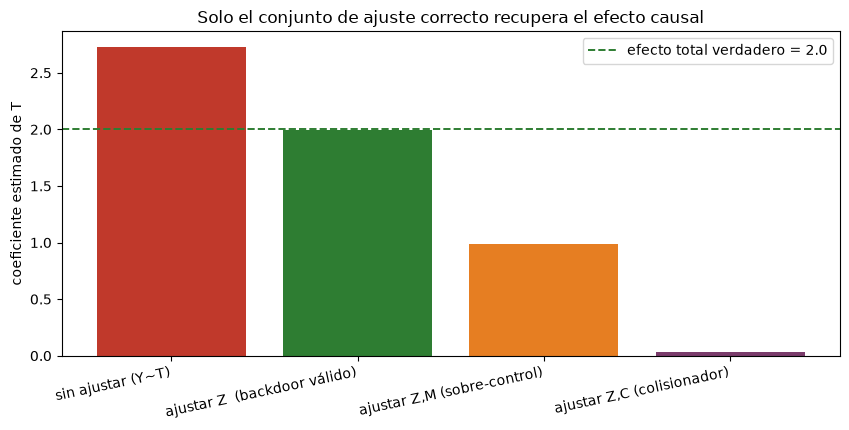

  sin ajustar (Y~T)              = +2.730
  ajustar Z  (backdoor válido)   = +1.995
  ajustar Z,M (sobre-control)    = +0.983
  ajustar Z,C (colisionador)     = +0.032


In [7]:
# Demostración cuantitativa: efecto total verdadero = 2.0 (directo 1.0 + indirecto 1.0×1.0)
def simular_tratamiento(n=8000, seed=0):
    r = np.random.default_rng(seed)
    Z = r.normal(0, 1, n)
    T = 0.8 * Z + r.normal(0, 1, n)
    M = 1.0 * T + r.normal(0, 1, n)
    Y = 1.5 * Z + 1.0 * T + 1.0 * M + r.normal(0, 1, n)
    C = 1.0 * T + 1.0 * Y + r.normal(0, 1, n)
    return pd.DataFrame({"Z": Z, "T": T, "M": M, "Y": Y, "C": C})

def coef_T(df, ajuste):
    cols = ["T"] + list(ajuste)
    return LinearRegression().fit(df[cols], df["Y"]).coef_[0]

dft = simular_tratamiento()
efecto_total = 2.0
estim = {
    "sin ajustar (Y~T)":            coef_T(dft, []),
    "ajustar Z  (backdoor válido)": coef_T(dft, ["Z"]),
    "ajustar Z,M (sobre-control)":  coef_T(dft, ["Z", "M"]),
    "ajustar Z,C (colisionador)":   coef_T(dft, ["Z", "C"]),
}
plt.figure(figsize=(8.6, 4.4))
colores = ["#c0392b", "#2e7d32", "#e67e22", "#7a3b6b"]
plt.bar(list(estim), [v for v in estim.values()], color=colores)
plt.axhline(efecto_total, color="#2e7d32", ls="--", lw=1.4, label=f"efecto total verdadero = {efecto_total}")
plt.ylabel("coeficiente estimado de T"); plt.xticks(rotation=12, ha="right")
plt.title("Solo el conjunto de ajuste correcto recupera el efecto causal")
plt.legend(); plt.tight_layout(); plt.show()
for k, v in estim.items():
    print(f"  {k:30s} = {v:+.3f}")

**Lectura.** Solo **ajustar por $Z$** (el confusor) recupera el efecto total ($\approx 2.0$). *Sin ajustar*, el confusor infla la estimación; *ajustar también por el mediador $M$* da el efecto **directo** ($\approx 1.0$), no el total (sobre-control); *ajustar por el colisionador $C$* introduce sesgo. El criterio backdoor —puramente gráfico— predice el único ajuste correcto **sin mirar los datos**.

## Sección 5 · Un DAG para el programa de empleo (NSW)

Apliquemos lo anterior al cuaderno 05. Las covariables —edad, educación, etnia, estado civil e **ingreso previo** (`re75`)— son **anteriores** al tratamiento e influyen tanto en quién entra al programa como en el ingreso futuro: son **confusores**. El tratamiento afecta al ingreso de 1978. No hay mediadores ni colisionadores medidos post-tratamiento en estos datos.

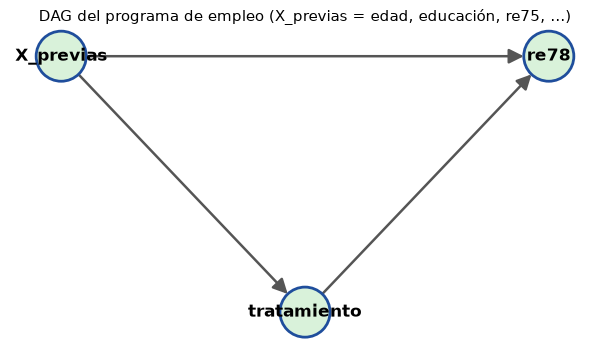

Camino de puerta trasera: tratamiento ← X_previas → re78
Conjunto de ajuste válido (criterio backdoor): {X_previas}
=> el ajuste por las covariables PREVIAS identifica el efecto;
   por eso en el cuaderno 05 la regresión ajustada redujo gran parte del sesgo,
   y por eso NUNCA debe ajustarse por variables posteriores al tratamiento.


In [8]:
# DAG del NSW: covariables previas confunden tratamiento e ingreso futuro
Gnsw = nx.DiGraph()
Gnsw.add_edges_from([("X_previas", "tratamiento"), ("X_previas", "re78"),
                     ("tratamiento", "re78")])
posn = {"X_previas": (0, 1), "tratamiento": (1, 0), "re78": (2, 1)}
fig, ax = plt.subplots(figsize=(6.2, 3.6))
dibujar_dag(Gnsw, posn, ax, "DAG del programa de empleo (X_previas = edad, educación, re75, …)",
            color_nodos="#d9f2da")
plt.tight_layout(); plt.show()

print("Camino de puerta trasera: tratamiento ← X_previas → re78")
print("Conjunto de ajuste válido (criterio backdoor): {X_previas}")
print("=> el ajuste por las covariables PREVIAS identifica el efecto;")
print("   por eso en el cuaderno 05 la regresión ajustada redujo gran parte del sesgo,")
print("   y por eso NUNCA debe ajustarse por variables posteriores al tratamiento.")

> **Observación 5.1.** El criterio backdoor justifica formalmente lo que en el cuaderno 05 era una intuición: **ajustar por las covariables previas** acercó la estimación observacional al valor experimental. Que no lo igualara del todo se debe a (i) posibles **confusores no medidos** (la ignorabilidad condicional no es verificable) y (ii) la **forma funcional** del ajuste lineal —limitaciones que los estimadores del cuaderno 07–08 atacan—. El grafo dice *qué* ajustar; los próximos cuadernos, *cómo*.

## Sección 6 · El criterio de puerta delantera (*front-door*)

El criterio de puerta trasera exige **medir** los confusores. ¿Y si el confusor $U$ es **no observado** y no hay forma de ajustarlo? A veces el efecto sigue siendo identificable, por una vía sorprendente: a través de un **mediador** que canalice todo el efecto.

> **Definición 6.1 (criterio de puerta delantera).** Un conjunto $M$ satisface el *criterio frontdoor* respecto de $(T,Y)$ si:
> 1. $M$ **intercepta todos** los caminos dirigidos de $T$ a $Y$ (media el efecto por completo);
> 2. no hay camino de **puerta trasera** abierto de $T$ a $M$;
> 3. **todos** los caminos de puerta trasera de $M$ a $Y$ están bloqueados por $T$.

> **Teorema 6.1 (ajuste de puerta delantera; Pearl, 2009).** Bajo el criterio anterior, el efecto causal está identificado **aunque exista un confusor no observado** de $T$ y $Y$:
> $$ P\big(Y\mid do(T{=}t)\big)=\sum_{m}P(m\mid t)\sum_{t'}P(Y\mid m,t')\,P(t'). $$
> La fórmula encadena **dos** ajustes válidos: el de $T\to M$ (sin confusión, condición 2) y el de $M\to Y$ ajustando por $T$ (condición 3). En un modelo lineal, el efecto es el **producto** de ambos coeficientes.

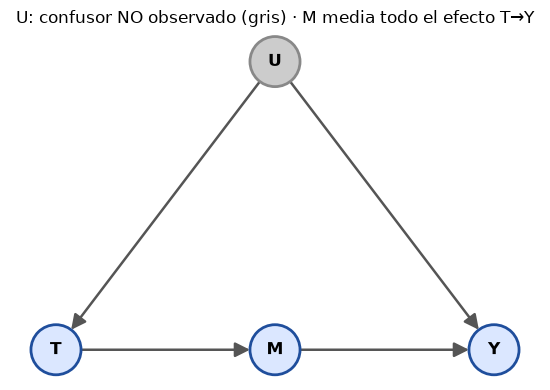

In [9]:
# DAG con confusor NO observado U y mediador M que canaliza todo el efecto
Gfd = nx.DiGraph([("U", "T"), ("U", "Y"), ("T", "M"), ("M", "Y")])
posfd = {"U": (1, 1.7), "T": (0, 0.6), "M": (1, 0.6), "Y": (2, 0.6)}
fig, ax = plt.subplots(figsize=(5.6, 4))
col = ["#cccccc" if v == "U" else "#dbe7ff" for v in Gfd.nodes]
bor = ["#888888" if v == "U" else "#1f4e9c" for v in Gfd.nodes]
nx.draw_networkx_nodes(Gfd, posfd, ax=ax, node_color=col, node_size=1300, edgecolors=bor, linewidths=2)
nx.draw_networkx_labels(Gfd, posfd, ax=ax, font_size=12, font_weight="bold")
nx.draw_networkx_edges(Gfd, posfd, ax=ax, arrowsize=22, edge_color="#555", width=1.8, node_size=1300)
ax.set_title("U: confusor NO observado (gris) · M media todo el efecto T→Y"); ax.axis("off")
plt.tight_layout(); plt.show()

In [10]:
# Demostración numérica: el frontdoor identifica pese a U no observado (efecto verdadero = 0.8)
r = np.random.default_rng(0); n = 20000
U = r.normal(0, 1, n)                       # confusor NO observado
T = 1.5 * U + r.normal(0, 1, n)             # T <- U
M = 0.8 * T + r.normal(0, 1, n)             # T -> M (no tocado por U)
Y = 1.0 * M + 2.0 * U + r.normal(0, 1, n)   # Y <- M, Y <- U
dffd = pd.DataFrame({"T": T, "M": M, "Y": Y})

naive = LinearRegression().fit(dffd[["T"]], dffd["Y"]).coef_[0]      # sesgado por U
b = LinearRegression().fit(dffd[["T"]], dffd["M"]).coef_[0]          # T -> M (sin confusión)
c = LinearRegression().fit(dffd[["M", "T"]], dffd["Y"]).coef_[0]     # M -> Y | T
print(f"efecto verdadero (b·c = 0.8·1.0)        = 0.800")
print(f"OLS ingenuo Y~T (sesgado por U)         = {naive:.3f}")
print(f"frontdoor:  b(T→M)={b:.3f} · c(M→Y|T)={c:.3f}  =>  b·c = {b*c:.3f}")
print(f"\n(el backdoor es IMPOSIBLE: U no se observa; el frontdoor identifica igual)")

efecto verdadero (b·c = 0.8·1.0)        = 0.800
OLS ingenuo Y~T (sesgado por U)         = 1.722
frontdoor:  b(T→M)=0.801 · c(M→Y|T)=0.992  =>  b·c = 0.795

(el backdoor es IMPOSIBLE: U no se observa; el frontdoor identifica igual)


> **Observación 6.1.** El frontdoor es el **dual** del backdoor: donde aquel *bloquea* los caminos no causales condicionando confusores, este *aprovecha* un camino causal completamente mediado. La identificación se logra **sin medir $U$** —algo que parecía imposible—, a costa de un supuesto fuerte y poco común: que exista un mediador $M$ que canalice **todo** el efecto y que no comparta confusión con $Y$ salvo a través de $T$. Junto con el backdoor y la regla de la intervención, el frontdoor es un caso particular del **do-cálculo** de Pearl (Sección 7), el sistema completo para decidir qué efectos son identificables a partir de un grafo.

## Sección 7 · Buenos y malos controles, y el do-cálculo

La práctica habitual de "controlar por todas las covariables disponibles" es **errónea**. El grafo clasifica cada candidato a control, y algunos —lejos de ayudar— **introducen** o **amplifican** el sesgo.

> **Definición 7.1 (buen / mal control).** Una covariable es un *buen control* si, al incluirla en el ajuste, **reduce o no altera** el sesgo del efecto estimado; es un *mal control* si lo **introduce o amplifica**. La clasificación depende solo de la posición de la variable en el DAG, no de los datos (Cinelli, Forney & Pearl, 2024).

| Estructura del candidato $Z$ | Rol | ¿Incluir? | Efecto de incluirlo |
|---|---|---|---|
| $T\leftarrow Z\to Y$ | **confusor** | **Sí** | cierra una puerta trasera (quita sesgo) |
| $T\to Z\to Y$ | mediador | No | sobre-control: borra el efecto indirecto |
| $T\to Z\leftarrow Y$ | colisionador | No | abre un camino espurio (sesgo de colisionador) |
| $A\to Z\leftarrow B$, con $A\to T$, $B\to Y$ | M-bias | No | condicionar el colisionador conecta $T$ y $Y$ (Ejemplo 2) |
| $Y\to Z$ | descendiente del resultado | No | introduce sesgo (es efecto, no causa) |
| $Z\to T$ (con confusor **no observado**) | instrumento | No | **amplifica** el sesgo de confusión |
| $Z\to Y$ (no $\to T$) | covariable de precisión | Sí (para varianza) | no cambia el sesgo; **reduce el error estándar** |

Los dos últimos son los menos intuitivos; los verificamos numéricamente.

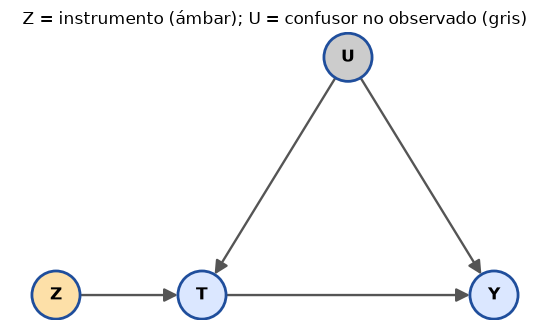

efecto verdadero        = 1.00
ingenuo  Y~T            = 1.664  (sesgo +0.664)
controlando Z  Y~T+Z    = 1.999  (sesgo +0.999)  <- el instrumento AMPLIFICA el sesgo


In [11]:
# Mal control: condicionar un INSTRUMENTO amplifica el sesgo (confusor U no observado)
import statsmodels.formula.api as smf
r = np.random.default_rng(0); n = 20000; beta = 1.0
U = r.normal(0, 1, n); Z = r.normal(0, 1, n)            # U no observado; Z instrumento (Z->T)
T = Z + U + r.normal(0, 1, n)
Y = beta * T + 2.0 * U + r.normal(0, 1, n)
d = pd.DataFrame({"T": T, "Y": Y, "Z": Z})
b_naive = smf.ols("Y ~ T", d).fit().params["T"]
b_z = smf.ols("Y ~ T + Z", d).fit().params["T"]

Gz = nx.DiGraph([("Z", "T"), ("U", "T"), ("U", "Y"), ("T", "Y")])
posz = {"Z": (-1, 0), "T": (0, 0), "Y": (2, 0), "U": (1, 1.2)}
fig, ax = plt.subplots(figsize=(5.6, 3.4))
col = ["#cccccc" if v == "U" else "#fde0a8" if v == "Z" else "#dbe7ff" for v in Gz.nodes]
nx.draw_networkx_nodes(Gz, posz, ax=ax, node_color=col, node_size=1200, edgecolors="#1f4e9c", linewidths=2)
nx.draw_networkx_labels(Gz, posz, ax=ax, font_size=12, font_weight="bold")
nx.draw_networkx_edges(Gz, posz, ax=ax, arrowsize=20, edge_color="#555", width=1.7, node_size=1200)
ax.set_title("Z = instrumento (ámbar); U = confusor no observado (gris)"); ax.axis("off")
plt.tight_layout(); plt.show()
print(f"efecto verdadero        = {beta:.2f}")
print(f"ingenuo  Y~T            = {b_naive:.3f}  (sesgo {b_naive-beta:+.3f})")
print(f"controlando Z  Y~T+Z    = {b_z:.3f}  (sesgo {b_z-beta:+.3f})  <- el instrumento AMPLIFICA el sesgo")

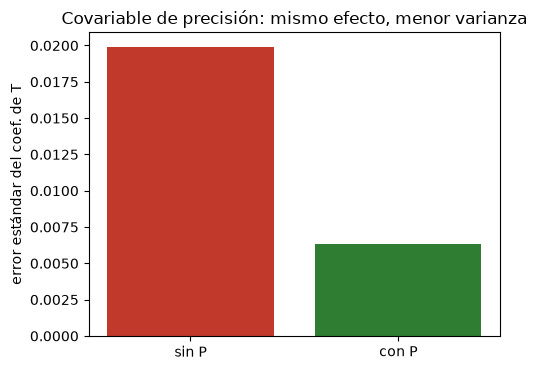

sin P: coef T = 1.008  SE = 0.020
con P: coef T = 1.003  SE = 0.006   <- mismo coef, SE mucho menor


In [12]:
# Buen control de precisión: P->Y (no ->T) no cambia el sesgo y reduce el error estándar
r = np.random.default_rng(1); n = 20000
P = r.normal(0, 1, n); X = r.normal(0, 1, n)
Tp = 0.5 * X + r.normal(0, 1, n)
Yp = 1.0 * Tp + 3.0 * P + r.normal(0, 1, n)            # P explica mucha varianza de Y, no afecta a T
dp = pd.DataFrame({"T": Tp, "Y": Yp, "P": P})
m1 = smf.ols("Y ~ T", dp).fit(); m2 = smf.ols("Y ~ T + P", dp).fit()
plt.figure(figsize=(5.2, 3.8))
plt.bar(["sin P", "con P"], [m1.bse["T"], m2.bse["T"]], color=["#c0392b", "#2e7d32"])
plt.ylabel("error estándar del coef. de T")
plt.title("Covariable de precisión: mismo efecto, menor varianza")
plt.tight_layout(); plt.show()
print(f"sin P: coef T = {m1.params['T']:.3f}  SE = {m1.bse['T']:.3f}")
print(f"con P: coef T = {m2.params['T']:.3f}  SE = {m2.bse['T']:.3f}   <- mismo coef, SE mucho menor")

### El do-cálculo: el sistema completo de identificación

Backdoor y frontdoor son **casos particulares** de un sistema más general que decide, para *cualquier* grafo, si un efecto $P(y\mid do(x))$ es expresable en términos observacionales.

> **Definición 7.2 (do-cálculo; Pearl, 1995).** Sean $G_{\overline X}$ el grafo tras **borrar las flechas que entran** a $X$ y $G_{\underline X}$ tras borrar las que **salen** de $X$. Para conjuntos disjuntos $X,Y,Z,W$:
> - **R1 (insertar/eliminar observaciones):** $P(y\mid do(x),z,w)=P(y\mid do(x),w)$ si $(Y\perp Z\mid X,W)$ en $G_{\overline X}$.
> - **R2 (intercambiar acción y observación):** $P(y\mid do(x),do(z),w)=P(y\mid do(x),z,w)$ si $(Y\perp Z\mid X,W)$ en $G_{\overline X\,\underline Z}$.
> - **R3 (insertar/eliminar acciones):** $P(y\mid do(x),do(z),w)=P(y\mid do(x),w)$ si $(Y\perp Z\mid X,W)$ en $G_{\overline X\,\overline{Z(W)}}$.

> **Observación 7.1 (completitud).** El do-cálculo es **completo** (Shpitser & Pearl, 2006; Huang & Valtorta, 2006): si un efecto es identificable a partir del grafo, las tres reglas producen una fórmula observacional para estimarlo; si **no** lo es, ninguna técnica puede estimarlo sin supuestos adicionales. El grafo —no los datos— fija la **frontera de lo estimable**. (DoWhy, en el cuaderno 07, automatiza esta búsqueda.)

## Sección 8 · Descubrimiento causal desde los datos

Hasta aquí el DAG se daba por conocido (del dominio). ¿Se puede **aprender** la estructura a partir de los datos? Sí, pero con un límite fundamental: los datos observacionales no distinguen entre DAGs que implican **las mismas independencias condicionales**.

> **Definición 8.1 (equivalencia de Markov).** Dos DAGs son *Markov equivalentes* si codifican exactamente el mismo conjunto de independencias condicionales (d-separaciones). Una clase de equivalencia se representa con un **CPDAG** (grafo parcialmente dirigido): aristas **dirigidas** donde la orientación es forzosa, y **no dirigidas** donde es ambigua.

> **Teorema 8.1 (Verma & Pearl, 1990).** Dos DAGs son Markov equivalentes **si y solo si** tienen el mismo *esqueleto* (las mismas aristas, sin orientar) y las mismas **v-estructuras** (colisionadores $X\to Z\leftarrow Y$ con $X,Y$ no adyacentes).
>
> **Consecuencia.** $X\to Y$ y $X\leftarrow Y$ son indistinguibles con datos observacionales (misma independencia: ninguna). Pero un colisionador $X\to Z\leftarrow Y$ **sí** es identificable, porque implica $X\perp Y$ pero $X\not\perp Y\mid Z$ —una firma observable—.

> **Definición 8.2 (algoritmo PC).** Método *basado en restricciones* (Spirtes & Glymour, 1991): (1) parte del grafo completo y **elimina** aristas según pruebas de independencia condicional (obteniendo el esqueleto); (2) **orienta las v-estructuras**; (3) propaga orientaciones con las **reglas de Meek** sin crear nuevos colisionadores ni ciclos.

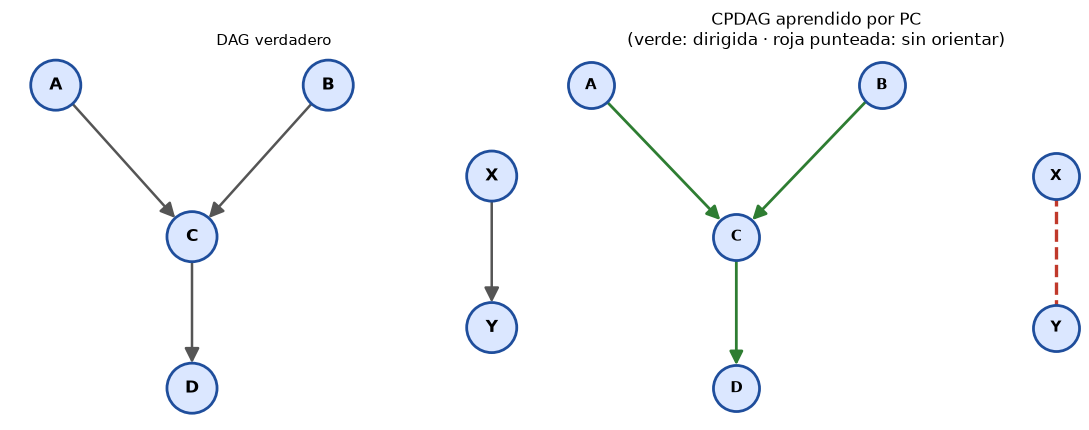

Aristas recuperadas por PC:
  A -> C
  B -> C
  C -> D
  X -- Y  (sin orientar: equivalencia de Markov)


In [13]:
# Descubrimiento con PC: recuperar la clase de equivalencia de un DAG conocido
import warnings; warnings.filterwarnings("ignore")
from causallearn.search.ConstraintBased.PC import pc

r = np.random.default_rng(0); n = 5000
A = r.normal(0, 1, n); B = r.normal(0, 1, n)
C = A + B + r.normal(0, 1, n); D = C + r.normal(0, 1, n)     # A->C<-B (colisionador), C->D
X = r.normal(0, 1, n); Y = X + r.normal(0, 1, n)             # X->Y (cadena de 2, no orientable)
datos = np.column_stack([A, B, C, D, X, Y]); nombres = ["A", "B", "C", "D", "X", "Y"]
cg = pc(datos, 0.05, indep_test="fisherz", show_progress=False)
g = cg.G.graph

def dibujar_cpdag(g, nombres, pos, ax, titulo):
    Gd = nx.DiGraph(); Gd.add_nodes_from(nombres); Gu = nx.Graph()
    for a in range(len(nombres)):
        for b in range(a + 1, len(nombres)):
            x, y = g[a][b], g[b][a]
            if x == -1 and y == 1:   Gd.add_edge(nombres[a], nombres[b])
            elif x == 1 and y == -1: Gd.add_edge(nombres[b], nombres[a])
            elif x == -1 and y == -1: Gu.add_edge(nombres[a], nombres[b])
    nx.draw_networkx_nodes(Gd, pos, ax=ax, node_color="#dbe7ff", node_size=1100, edgecolors="#1f4e9c", linewidths=2, nodelist=nombres)
    nx.draw_networkx_labels(Gd, pos, ax=ax, font_size=11, font_weight="bold")
    nx.draw_networkx_edges(Gd, pos, ax=ax, arrowsize=20, edge_color="#2e7d32", width=2, node_size=1100)
    nx.draw_networkx_edges(Gu, pos, ax=ax, edge_color="#c0392b", width=2.4, style="dashed")
    ax.set_title(titulo); ax.axis("off")

pos = {"A": (0, 2), "B": (2, 2), "C": (1, 1), "D": (1, 0), "X": (3.2, 1.4), "Y": (3.2, 0.4)}
Gtrue = nx.DiGraph([("A", "C"), ("B", "C"), ("C", "D"), ("X", "Y")])
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
dibujar_dag(Gtrue, pos, ax[0], "DAG verdadero")
dibujar_cpdag(g, nombres, pos, ax[1], "CPDAG aprendido por PC\n(verde: dirigida · roja punteada: sin orientar)")
plt.tight_layout(); plt.show()

print("Aristas recuperadas por PC:")
for a in range(6):
    for b in range(a + 1, 6):
        x, y = g[a][b], g[b][a]
        if x == -1 and y == 1:   print(f"  {nombres[a]} -> {nombres[b]}")
        elif x == 1 and y == -1: print(f"  {nombres[b]} -> {nombres[a]}")
        elif x == -1 and y == -1: print(f"  {nombres[a]} -- {nombres[b]}  (sin orientar: equivalencia de Markov)")

> **Observación 8.1.** El PC recupera el **colisionador** ($A\to C\leftarrow B$) y, por las reglas de Meek, $C\to D$; pero deja $X-Y$ **sin orientar**, porque con datos observacionales $X\to Y$ y $X\leftarrow Y$ son indistinguibles. La estructura que se aprende es la **clase de equivalencia**, no el DAG. Orientar las aristas restantes exige **intervenciones** (experimentos) o **conocimiento del dominio**. Por eso el DAG del NSW (Sección 5) no se "descubrió" de los datos sino que se justificó por el **orden temporal**: las covariables son *previas* al tratamiento, lo que orienta sus flechas. El descubrimiento causal *propone* hipótesis estructurales; la sustancia las *confirma*.

## Síntesis

- Un **DAG** codifica las causas directas; todo camino se compone de **cadenas, bifurcaciones y colisionadores**.
- La **d-separación** (Def. 2.2) traduce el grafo en independencias condicionales (**Teorema 2.1**): la correlación parcial se anula exactamente cuando hay d-separación.
- Tres roles: **confusor** → ajustar; **mediador** → no (sobre-control); **colisionador** → no (sesgo inducido). El catálogo completo de **buenos y malos controles** (Sección 7) añade el *descendiente*, el *M-bias*, la **amplificación de sesgo** al condicionar un instrumento y la *covariable de precisión*.
- El **criterio de puerta trasera** (Teorema 4.1) identifica el conjunto de ajuste correcto; cuando el confusor es **no observado**, el **criterio de puerta delantera** (Teorema 6.1) aún puede identificar el efecto vía un mediador. Ambos son corolarios del **do-cálculo**, que es **completo**: el grafo fija la frontera de lo estimable.
- Desde **datos observacionales** solo se recupera la **clase de equivalencia de Markov** (el PC orienta los colisionadores, no las cadenas); orientar el resto exige intervenciones o conocimiento del dominio.
- En el NSW, el conjunto de ajuste válido son las **covariables previas**. El cuaderno 07 usa este grafo para **estimar** con DoWhy (identificar → estimar → refutar).

## Ejemplos complementarios

Cinco ejemplos desarrollados que afinan el criterio.

### Ejemplo 1 · Sobre-control: ajustar por un mediador subestima el efecto total

Se compara el coeficiente de $T$ ajustando o no por el mediador $M$: ajustarlo deja solo el efecto **directo**.

In [14]:
print(f"efecto TOTAL  (ajustar Z)      = {coef_T(dft, ['Z']):+.3f}   (verdadero 2.0)")
print(f"efecto DIRECTO (ajustar Z y M)   = {coef_T(dft, ['Z','M']):+.3f}   (verdadero 1.0)")
print("Ajustar por el mediador responde otra pregunta (efecto directo), no el efecto total.")

efecto TOTAL  (ajustar Z)      = +1.995   (verdadero 2.0)
efecto DIRECTO (ajustar Z y M)   = +0.983   (verdadero 1.0)
Ajustar por el mediador responde otra pregunta (efecto directo), no el efecto total.


### Ejemplo 2 · Sesgo del colisionador (M-bias)

Dos confusores independientes $A\perp B$ que colisionan en $C$ ($A\to C\leftarrow B$), con $A\to T$ y $B\to Y$. Aunque $C$ *parece* una covariable, **condicionarla abre** el camino $T\leftarrow A\to C\leftarrow B\to Y$ e introduce sesgo, pese a que $C$ no es confusor.

In [15]:
def simular_mbias(n=8000, seed=1):
    r = np.random.default_rng(seed)
    A = r.normal(0,1,n); B = r.normal(0,1,n)
    C = A + B + r.normal(0,1,n)
    T = 0.9*A + r.normal(0,1,n)
    Y = 1.0*T + 0.9*B + r.normal(0,1,n)         # efecto verdadero de T = 1.0
    return pd.DataFrame({"A":A,"B":B,"C":C,"T":T,"Y":Y})
dm = simular_mbias()
print(f"sin ajustar (correcto aquí)   coef T = {LinearRegression().fit(dm[['T']],dm['Y']).coef_[0]:+.3f}  (verdadero 1.0)")
print(f"ajustar por C (colisionador)  coef T = {LinearRegression().fit(dm[['T','C']],dm['Y']).coef_[0]:+.3f}  <- sesgo introducido")

sin ajustar (correcto aquí)   coef T = +1.012  (verdadero 1.0)


ajustar por C (colisionador)  coef T = +0.834  <- sesgo introducido


### Ejemplo 3 · Más casos de d-separación

Se contrastan predicción gráfica y datos en el DAG de tratamiento `Gt` para varias consultas.

In [16]:
for x, y, S in [("Z","M",set()), ("Z","M",{"T"}), ("T","Y",set()), ("Z","C",{"T","Y"})]:
    print(f"  {x} ⟂d {y} | {str(set(S)):8s}: d-sep={str(d_separa(Gt,x,y,S)):5s} | "
          f"corr.parcial={corr_parcial(dft,x,y,S):+.3f}")

  Z ⟂d M | set()   : d-sep=False | corr.parcial=+0.491
  Z ⟂d M | {'T'}   : d-sep=True  | corr.parcial=-0.003
  T ⟂d Y | set()   : d-sep=False | corr.parcial=+0.884
  Z ⟂d C | {'Y', 'T'}: d-sep=True  | corr.parcial=+0.011


### Ejemplo 4 · El conjunto de ajuste no es único

Si existe otra variable previa $Z_2$ también confusora, tanto $\{Z\}$ como $\{Z,Z_2\}$ pueden ser válidos y dar la misma estimación; lo importante es **bloquear las puertas traseras**, no incluir todo.

In [17]:
def simular_dos_confusores(n=8000, seed=2):
    r = np.random.default_rng(seed)
    Z = r.normal(0,1,n); Z2 = r.normal(0,1,n)
    T = 0.7*Z + 0.7*Z2 + r.normal(0,1,n)
    Y = 1.0*T + 1.2*Z + 0.8*Z2 + r.normal(0,1,n)      # efecto verdadero = 1.0
    return pd.DataFrame({"Z":Z,"Z2":Z2,"T":T,"Y":Y})
d2 = simular_dos_confusores()
for aj in [["Z","Z2"], ["Z"], ["Z2"], []]:
    print(f"  ajustar {str(aj):14s} -> coef T = {LinearRegression().fit(d2[['T']+aj],d2['Y']).coef_[0]:+.3f}")
print("Solo bloquear AMBAS puertas (Z y Z2) recupera 1.0; con uno solo queda confusión residual.")

  ajustar ['Z', 'Z2']    -> coef T = +1.003
  ajustar ['Z']          -> coef T = +1.381
  ajustar ['Z2']         -> coef T = +1.567
  ajustar []             -> coef T = +1.713
Solo bloquear AMBAS puertas (Z y Z2) recupera 1.0; con uno solo queda confusión residual.


### Ejemplo 5 · Nunca ajustar por descendientes del tratamiento

Una variable posterior al tratamiento (aquí el mediador $M$, descendiente de $T$) viola la condición (i) del criterio backdoor. Se muestra que incluirla cambia el estimando.

In [18]:
print("Descendientes de T en el DAG Gt:", sorted(nx.descendants(Gt, "T")))
print(f"ajuste válido (solo Z, previo):     coef T = {coef_T(dft, ['Z']):+.3f}  (efecto total 2.0)")
print(f"ajuste inválido (incluye M, desc.): coef T = {coef_T(dft, ['Z','M']):+.3f}  (ya no es el total)")

Descendientes de T en el DAG Gt: ['C', 'M', 'Y']
ajuste válido (solo Z, previo):     coef T = +1.995  (efecto total 2.0)
ajuste inválido (incluye M, desc.): coef T = +0.983  (ya no es el total)


## Referencias (APA 7)

- Cinelli, C., Forney, A., & Pearl, J. (2024). A crash course in good and bad controls. *Sociological Methods & Research, 53*(3), 1071–1104.
- Greenland, S., Pearl, J., & Robins, J. M. (1999). Causal diagrams for epidemiologic research. *Epidemiology, 10*(1), 37–48.
- Hagberg, A., Schult, D., & Swart, P. (2008). Exploring network structure, dynamics, and function using NetworkX. *Proceedings of the 7th Python in Science Conference*, 11–15.
- Pearl, J. (2009). *Causality: Models, reasoning, and inference* (2nd ed.). Cambridge University Press.
- Pearl, J., Glymour, M., & Jewell, N. P. (2016). *Causal inference in statistics: A primer*. Wiley.